In [9]:
from numpy import expand_dims
import numpy as np
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import matplotlib.pyplot as plt

In [11]:
img =load_img('data.jpeg')

In [12]:
data = img_to_array(img)
data.shape

(640, 640, 3)

In [13]:
samples = data[np.newaxis,:]
samples.shape

(1, 640, 640, 3)

In [15]:
datagen = ImageDataGenerator(vertical_flip = True, horizontal_flip=True, width_shift_range=[-200,200])

In [ ]:
it = datagen.flow(samples, batch_size=1) 

In [17]:
it

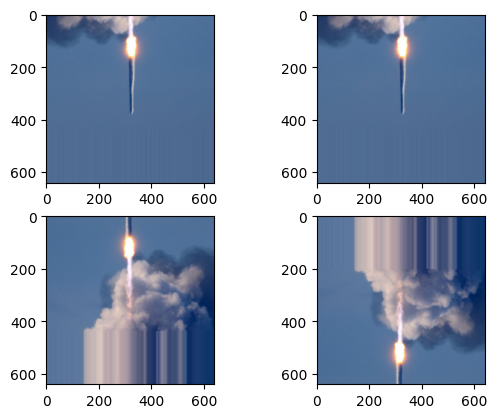

In [19]:
for i in range(4):
    plt.subplot(2,2,i+1)
    sub_image= next(it)
    image = sub_image[0].astype('uint8')
    plt.imshow(image)

In [21]:
sub_image.shape

(1, 640, 640, 3)

In [22]:
sub_image[0]

array([[[ 89., 117., 154.],
        [ 89., 117., 154.],
        [ 89., 117., 154.],
        ...,
        [ 11.,  50., 105.],
        [ 12.,  51., 106.],
        [ 14.,  53., 108.]],

       [[ 89., 117., 154.],
        [ 89., 117., 154.],
        [ 89., 117., 154.],
        ...,
        [ 11.,  50., 105.],
        [ 12.,  51., 106.],
        [ 14.,  53., 108.]],

       [[ 89., 117., 154.],
        [ 89., 117., 154.],
        [ 89., 117., 154.],
        ...,
        [ 11.,  50., 105.],
        [ 12.,  51., 106.],
        [ 14.,  53., 108.]],

       ...,

       [[ 78., 110., 149.],
        [ 78., 110., 149.],
        [ 77., 109., 148.],
        ...,
        [ 79., 111., 150.],
        [ 80., 112., 151.],
        [ 80., 112., 151.]],

       [[ 79., 111., 150.],
        [ 78., 110., 149.],
        [ 78., 110., 149.],
        ...,
        [ 79., 111., 150.],
        [ 80., 112., 151.],
        [ 80., 112., 151.]],

       [[ 80., 112., 151.],
        [ 79., 111., 150.],
        [ 78., 1

In [24]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions

In [25]:
model = ResNet50(weights = 'imagenet')

102967424/102967424 [==============================] - 30s 0us/step


In [ ]:
img_path = 'data.jpeg'
img = load_img(img_path, target_size = (224,224)) # resnet은 224 * 224로 고정 되어있음.
x = img_to_array(img)
x=x[np.newaxis, :]
x=preprocess_input(x)

In [27]:
preds = model.predict(x)
print('Predicted', decode_predictions(preds, top=3)[0])

35363/35363 [==============================] - 0s 1us/step
Predicted [('n04008634', 'projectile', 0.5033176), ('n03773504', 'missile', 0.42003337), ('n04266014', 'space_shuttle', 0.0765869)]


## 데이터 추가 zip파일 저장

In [ ]:
import os
import zipfile

# cats_and_dogs_filtered.zip 파일 정리하기
base_load = 'data/'

zip_ref = zipfile.ZipFile(base_load + 'cats_and_dogs_filtered.zip', 'r')

zip_ref.extractall(base_load)
zip_ref.close()

In [34]:
base_dir = 'data/cats_and_dogs_filtered'

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

In [35]:
train_dir

'data/cats_and_dogs_filtered\\train'

In [36]:
validation_dir

'data/cats_and_dogs_filtered\\validation'

In [41]:
train_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

In [43]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (150,150),
    batch_size = 20,
    class_mode = 'binary'
)

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size = (150,150),
    batch_size = 20,
    class_mode = 'binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [ ]:
# history = model.fit(train_generator, epochs=200, validation_data=validation_generator,
#                     steps_per_epoch = 7525//20+1, validation_steps = 480//20+1
#                     )

### fashion 파일 관리해보기

In [ ]:
# Footwear.zip 파일 정리하기
base_load = 'data/'

zip_ref = zipfile.ZipFile(base_load + 'Footwear.zip', 'r')

zip_ref.extractall(base_load)
zip_ref.close()

In [49]:
import pandas as pd

In [50]:
fashion_df = pd.read_csv('data/fashion.csv')

In [51]:
fashion_df.head()

,ProductId,Gender,Category,SubCategory,ProductType,Colour,Usage,ProductTitle,Image,ImageURL
0,42419,Girls,Apparel,Topwear,Tops,White,Casual,Gini and Jony Girls Knit White Top,42419.jpg,http://assets.myntassets.com/v1/images/style/p...
1,34009,Girls,Apparel,Topwear,Tops,Black,Casual,Gini and Jony Girls Black Top,34009.jpg,http://assets.myntassets.com/v1/images/style/p...
2,40143,Girls,Apparel,Topwear,Tops,Blue,Casual,Gini and Jony Girls Pretty Blossom Blue Top,40143.jpg,http://assets.myntassets.com/v1/images/style/p...
3,23623,Girls,Apparel,Topwear,Tops,Pink,Casual,Doodle Kids Girls Pink I love Shopping Top,23623.jpg,http://assets.myntassets.com/v1/images/style/p...
4,47154,Girls,Apparel,Bottomwear,Capris,Black,Casual,Gini and Jony Girls Black Capris,47154.jpg,http://assets.myntassets.com/v1/images/style/p...


In [52]:
footwear_men = fashion_df[fashion_df["Gender"]=="Men"]

In [53]:
footwear_men.head()

,ProductId,Gender,Category,SubCategory,ProductType,Colour,Usage,ProductTitle,Image,ImageURL
1326,9204,Men,Footwear,Shoes,Casual Shoes,Black,Casual,Puma Men Future Cat Remix SF Black Casual Shoes,9204.jpg,http://assets.myntassets.com/v1/images/style/p...
1327,18653,Men,Footwear,Flip Flops,Flip Flops,Black,Casual,Fila Men Cush Flex Black Slippers,18653.jpg,http://assets.myntassets.com/v1/images/style/p...
1328,12967,Men,Footwear,Sandal,Sandals,Black,Casual,ADIDAS Men Spry M Black Sandals,12967.jpg,http://assets.myntassets.com/v1/images/style/p...
1329,9036,Men,Footwear,Shoes,Formal Shoes,Black,Formal,Buckaroo Men Flores Black Formal Shoes,9036.jpg,http://assets.myntassets.com/v1/images/style/p...
1330,39988,Men,Footwear,Shoes,Casual Shoes,White,Casual,Gas Men Europa White Shoes,39988.jpg,http://assets.myntassets.com/v1/images/style/p...


In [55]:
footwear_men.info()

<class 'pandas.core.frame.DataFrame'>
Index: 811 entries, 1326 to 2136
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ProductId     811 non-null    int64 
 1   Gender        811 non-null    object
 2   Category      811 non-null    object
 3   SubCategory   811 non-null    object
 4   ProductType   811 non-null    object
 5   Colour        811 non-null    object
 6   Usage         811 non-null    object
 7   ProductTitle  811 non-null    object
 8   Image         811 non-null    object
 9   ImageURL      811 non-null    object
dtypes: int64(1), object(9)
memory usage: 69.7+ KB


In [56]:
img_width, img_height = 224, 224

train_data_dir = 'data/Footwear/Men/Images'

nb_train_samples = 811
epochs = 50
batch_size = 1

In [68]:
datagen = ImageDataGenerator(rescale=1./255)
generator = datagen.flow_from_directory(
    train_data_dir,
    target_size =(img_width, img_height),
    batch_size = batch_size,
    class_mode = None,
    shuffle=False
)

Found 811 images belonging to 1 classes.


In [73]:
itemcodes = []
for i in generator.filenames:
    itemcodes.append(i[(i.find('\\')+1):i.find(".")])

In [74]:
i

'images_with_product_ids\\9497.jpg'

In [75]:
i.find('\\')

23

In [77]:
i[(i.find('\\')+1) : (i.find('.'))]

'9497'

In [78]:
model = ResNet50(include_top=False, weights='imagenet')
ex_features = model.predict(generator, nb_train_samples // batch_size)

811/811 [==============================] - 14s 16ms/step


In [79]:
ex_features

array([[[[0.        , 0.        , 0.        , ..., 2.1091466 ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 1.6076745 ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 1.404785  ,
          0.        , 0.        ],
         ...,
         [0.        , 0.        , 0.        , ..., 1.7747467 ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 1.4949684 ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 3.2193918 ,
          0.        , 0.        ]],

        [[0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 2.6790004 ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 1.8862182 ,
          0.        , 0.        ],
         ...,
         [0.        , 0.        , 0.        , ..., 1.1119353 ,
          0.        , 0. 

In [80]:
ext_features = ex_features.reshape((811,7*7*2048))

In [82]:
ext_features.shape

(811, 100352)

In [97]:
np.save(open('./Men_ResNet50_features.npy', 'wb'), ext_features)
np.save(open('./Men_ResNet50_features_product_ids.npy', 'wb'), np.array(itemcodes))

In [99]:
!cp *.npy data/

'cp'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [100]:
import numpy as np
from sklearn.metrics import pairwise_distances

X = np.array([[0,0],[1,1],[2,2]])

In [101]:
D = pairwise_distances(X, np.array([[3,4]]), metric = 'euclidean')

In [102]:
print(D)

[[5.        ]
 [3.60555128]
 [2.23606798]]


In [103]:
Productid = itemcodes

In [104]:
product_id = '39972'

In [105]:
doc_id = Productid.index(product_id)

In [106]:
doc_id

488

In [108]:
distance =pairwise_distances(ext_features, ext_features[doc_id].reshape(1,-1))

In [109]:
np.array([[1,2,3,4]]).shape

(1, 4)

In [110]:
distance[:3]

array([[41.427525],
       [38.029976],
       [37.43155 ]], dtype=float32)

In [111]:
np.argsort(distance.flatten())[0:3]

array([488, 619, 173], dtype=int64)

In [112]:
np.sort(distance.flatten())[0:3]

array([ 0.      , 21.595566, 21.953585], dtype=float32)

In [135]:
indices = np.argsort(distance.flatten())[0:3]


In [136]:
ip_row = fashion_df[['ImageURL', 'ProductTitle']].loc[fashion_df['ProductId'] == int(Productid[indices[0]])]

In [137]:
from PIL import Image
from PIL import ImageFile
import urllib.request

GAS Men Grey Campus Casual Shoes


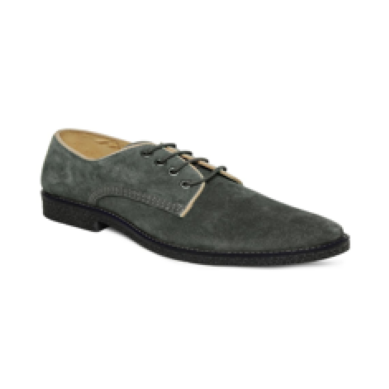

In [144]:
for idx, row in ip_row.iterrows():
    image = Image.open(urllib.request.urlopen(row['ImageURL']))
    image = image.resize((224,224))
    print(row['ProductTitle'])
    plt.imshow(image)
    plt.axis('off')

In [145]:
for idx, row in ip_row.iterrows():
    print(idx)
    print('========'*20)
    print(row)

1451
ImageURL        http://assets.myntassets.com/v1/images/style/p...
ProductTitle                     GAS Men Grey Campus Casual Shoes
Name: 1451, dtype: object
